In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import seaborn as sns
from scipy.signal import butter, filtfilt, iirnotch
import pywt
from tqdm import tqdm

### Reading ECG (Electrocardiogram) Signals


In [139]:
# patien_id with brugada type 2: 460919
# patiend_id with brugada type 1: 419960
# patiend_id normal: 251972
patient_id = '292666'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

In [140]:
signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs
duration = len(signals / sampling_freq) 

In [ ]:
def butter_bandpass(
    lowcut: float,
    highcut: float, 
    fs: float, 
    order: int = 4
  ):
  nyquist = 0.5 * fs
  low = lowcut / nyquist
  high = highcut / nyquist

  b, a = butter(order, [low, high], btype='band')
  return b, a

def butter_bandpass_filter(
    signal, 
    lowcut: float = 0.5, 
    highcut: float = 40.0, 
    fs: float = 100, 
    order: int = 4
  ):
  b, a = butter_bandpass(lowcut, highcut, fs, order=order)
  y = filtfilt(b, a, signal)
  return y

In [142]:
clean_bpf = np.zeros_like(signals)
for lead_index in range(signals.shape[1]):
  lead = signals[:, lead_index]
  lead = butter_bandpass_filter(lead, fs=sampling_freq)
  
  clean_bpf[:, lead_index] = lead

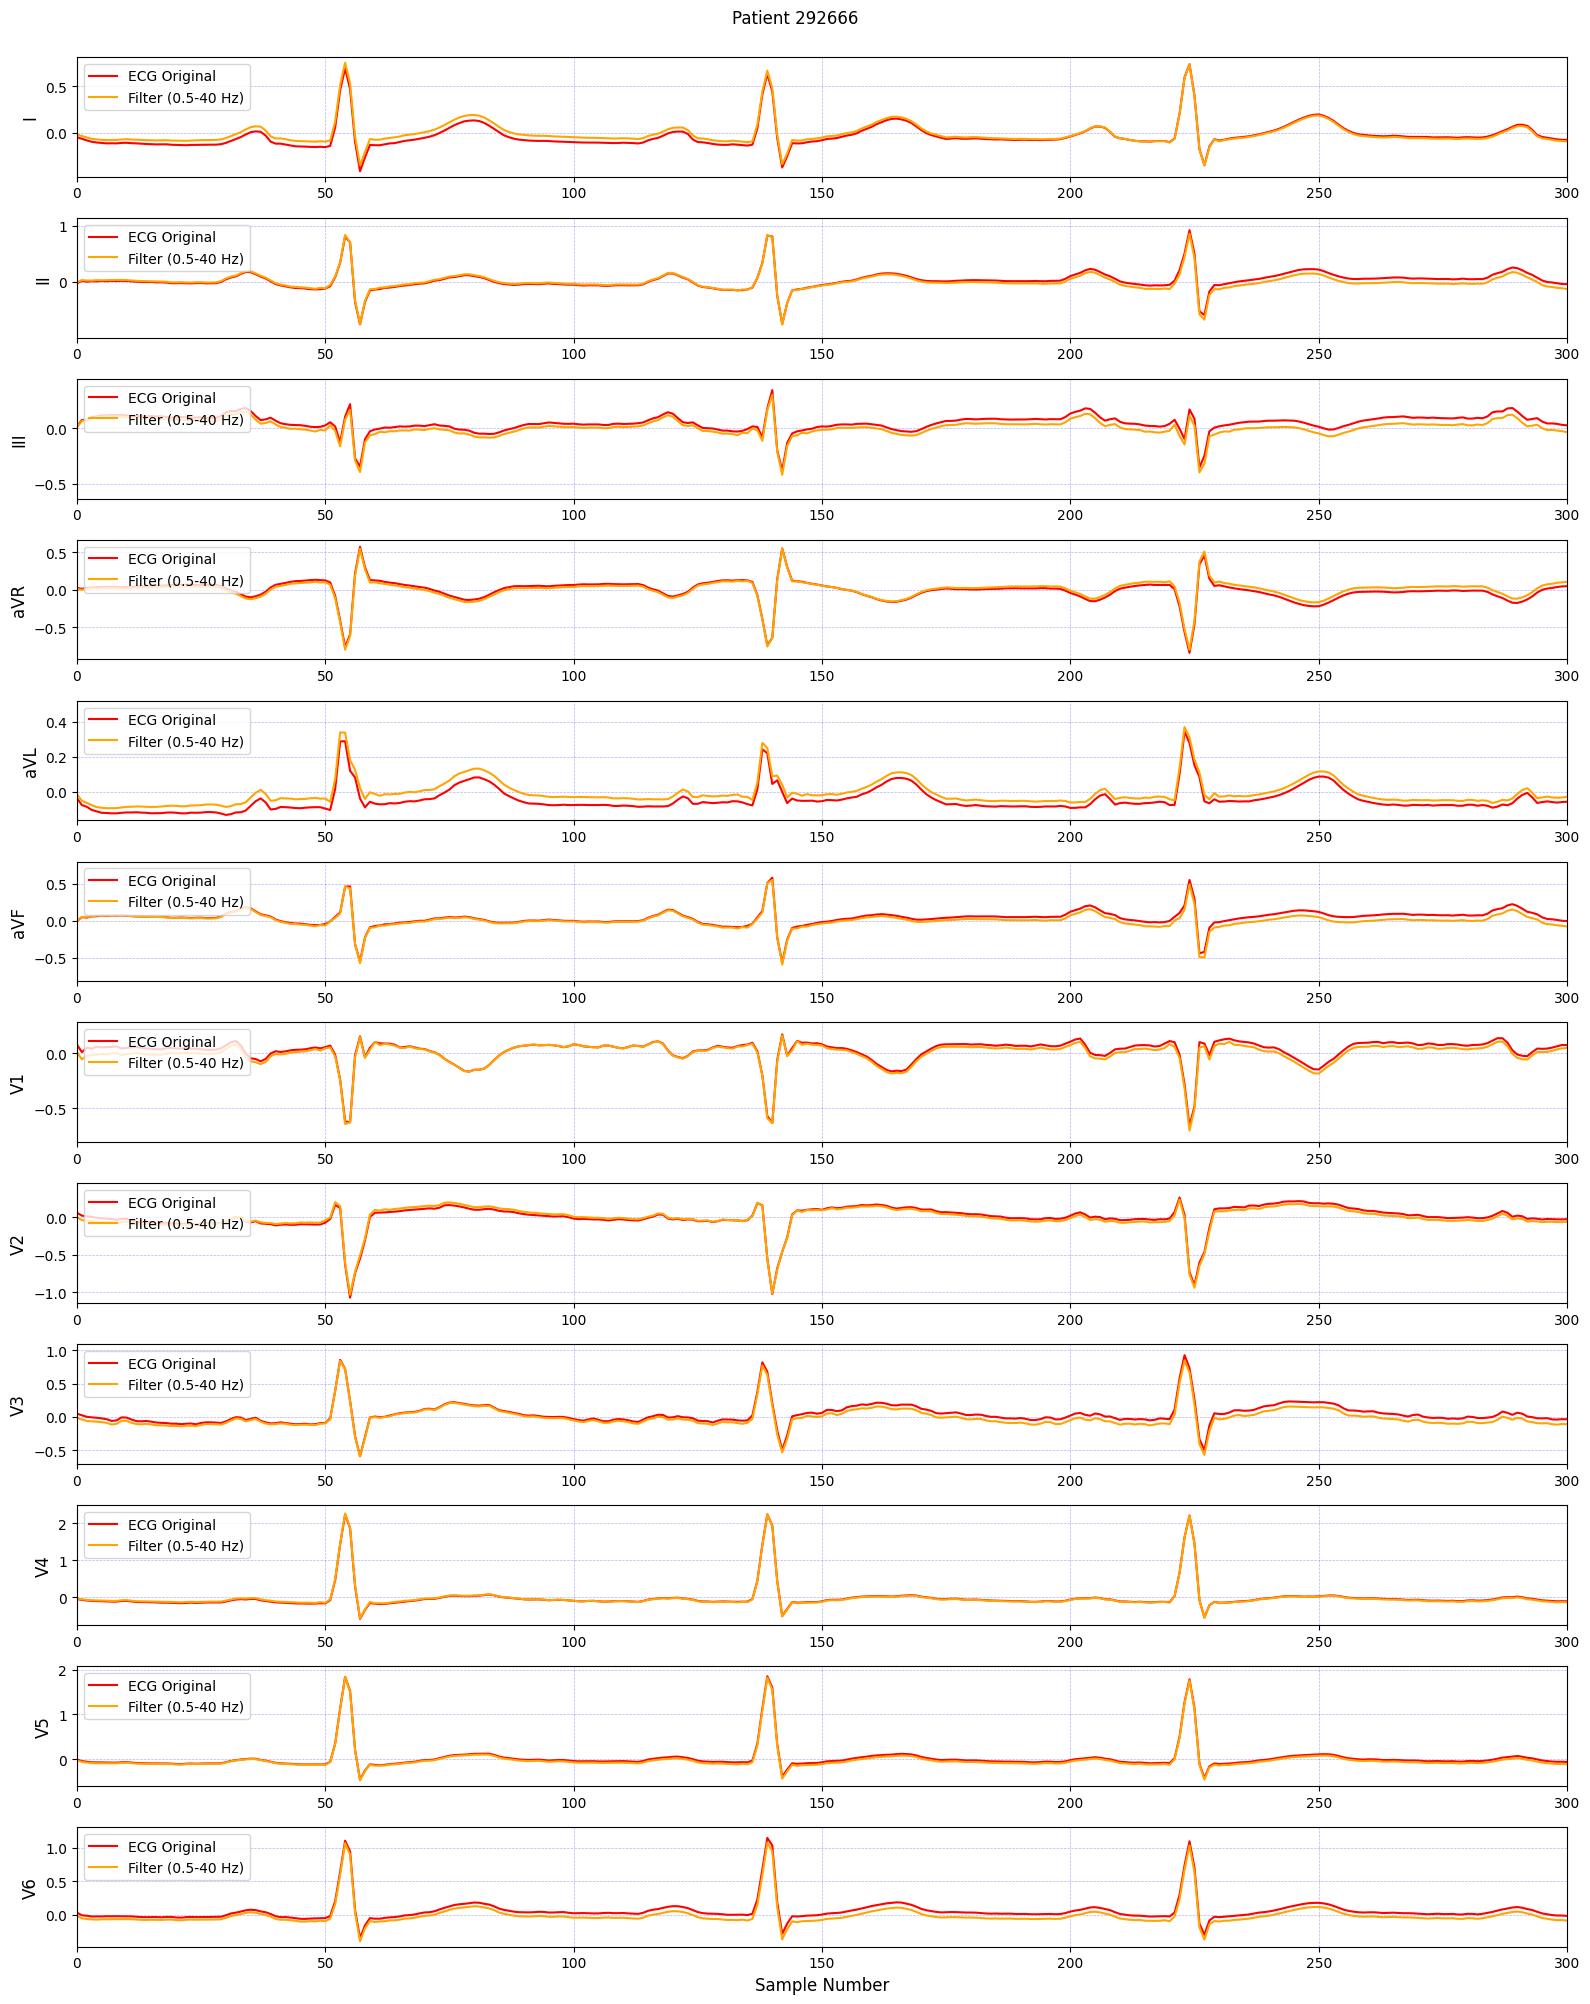

In [143]:
fig, axes = plt.subplots(12, 1, figsize=(16, 20))

for i, lead_name in enumerate(lead_names):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red')
  axes[i].plot(clean_bpf[:, i], linewidth=1.5, color='orange')
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].legend(['ECG Original', 'Filter (0.5-40 Hz)'], loc="upper left")
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='blue', alpha=0.3)

  # focusing waveform at specific time (0, duration)
  axes[i].set_xlim(0, 300) 

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()


#### Baseline Wander Removal

In [144]:
def butter_highpass(
  cutoff: float,
  fs: float,
  order: int = 5
):
  nyquist = 0.5 * fs
  b, a = butter(order, cutoff / nyquist, btype='high')
  return b, a


def remove_baseline_wander(signal, fs: float = 100.0):
  b, a = butter_highpass(0.5, fs)
  return filtfilt(b, a, signal)

In [145]:
clean_baseline_wonder = np.zeros_like(signals)
for lead_index in range(signals.shape[1]):
  lead = signals[:, lead_index]
  lead = remove_baseline_wander(lead, fs=sampling_freq)
  
  clean_baseline_wonder[:, lead_index] = lead

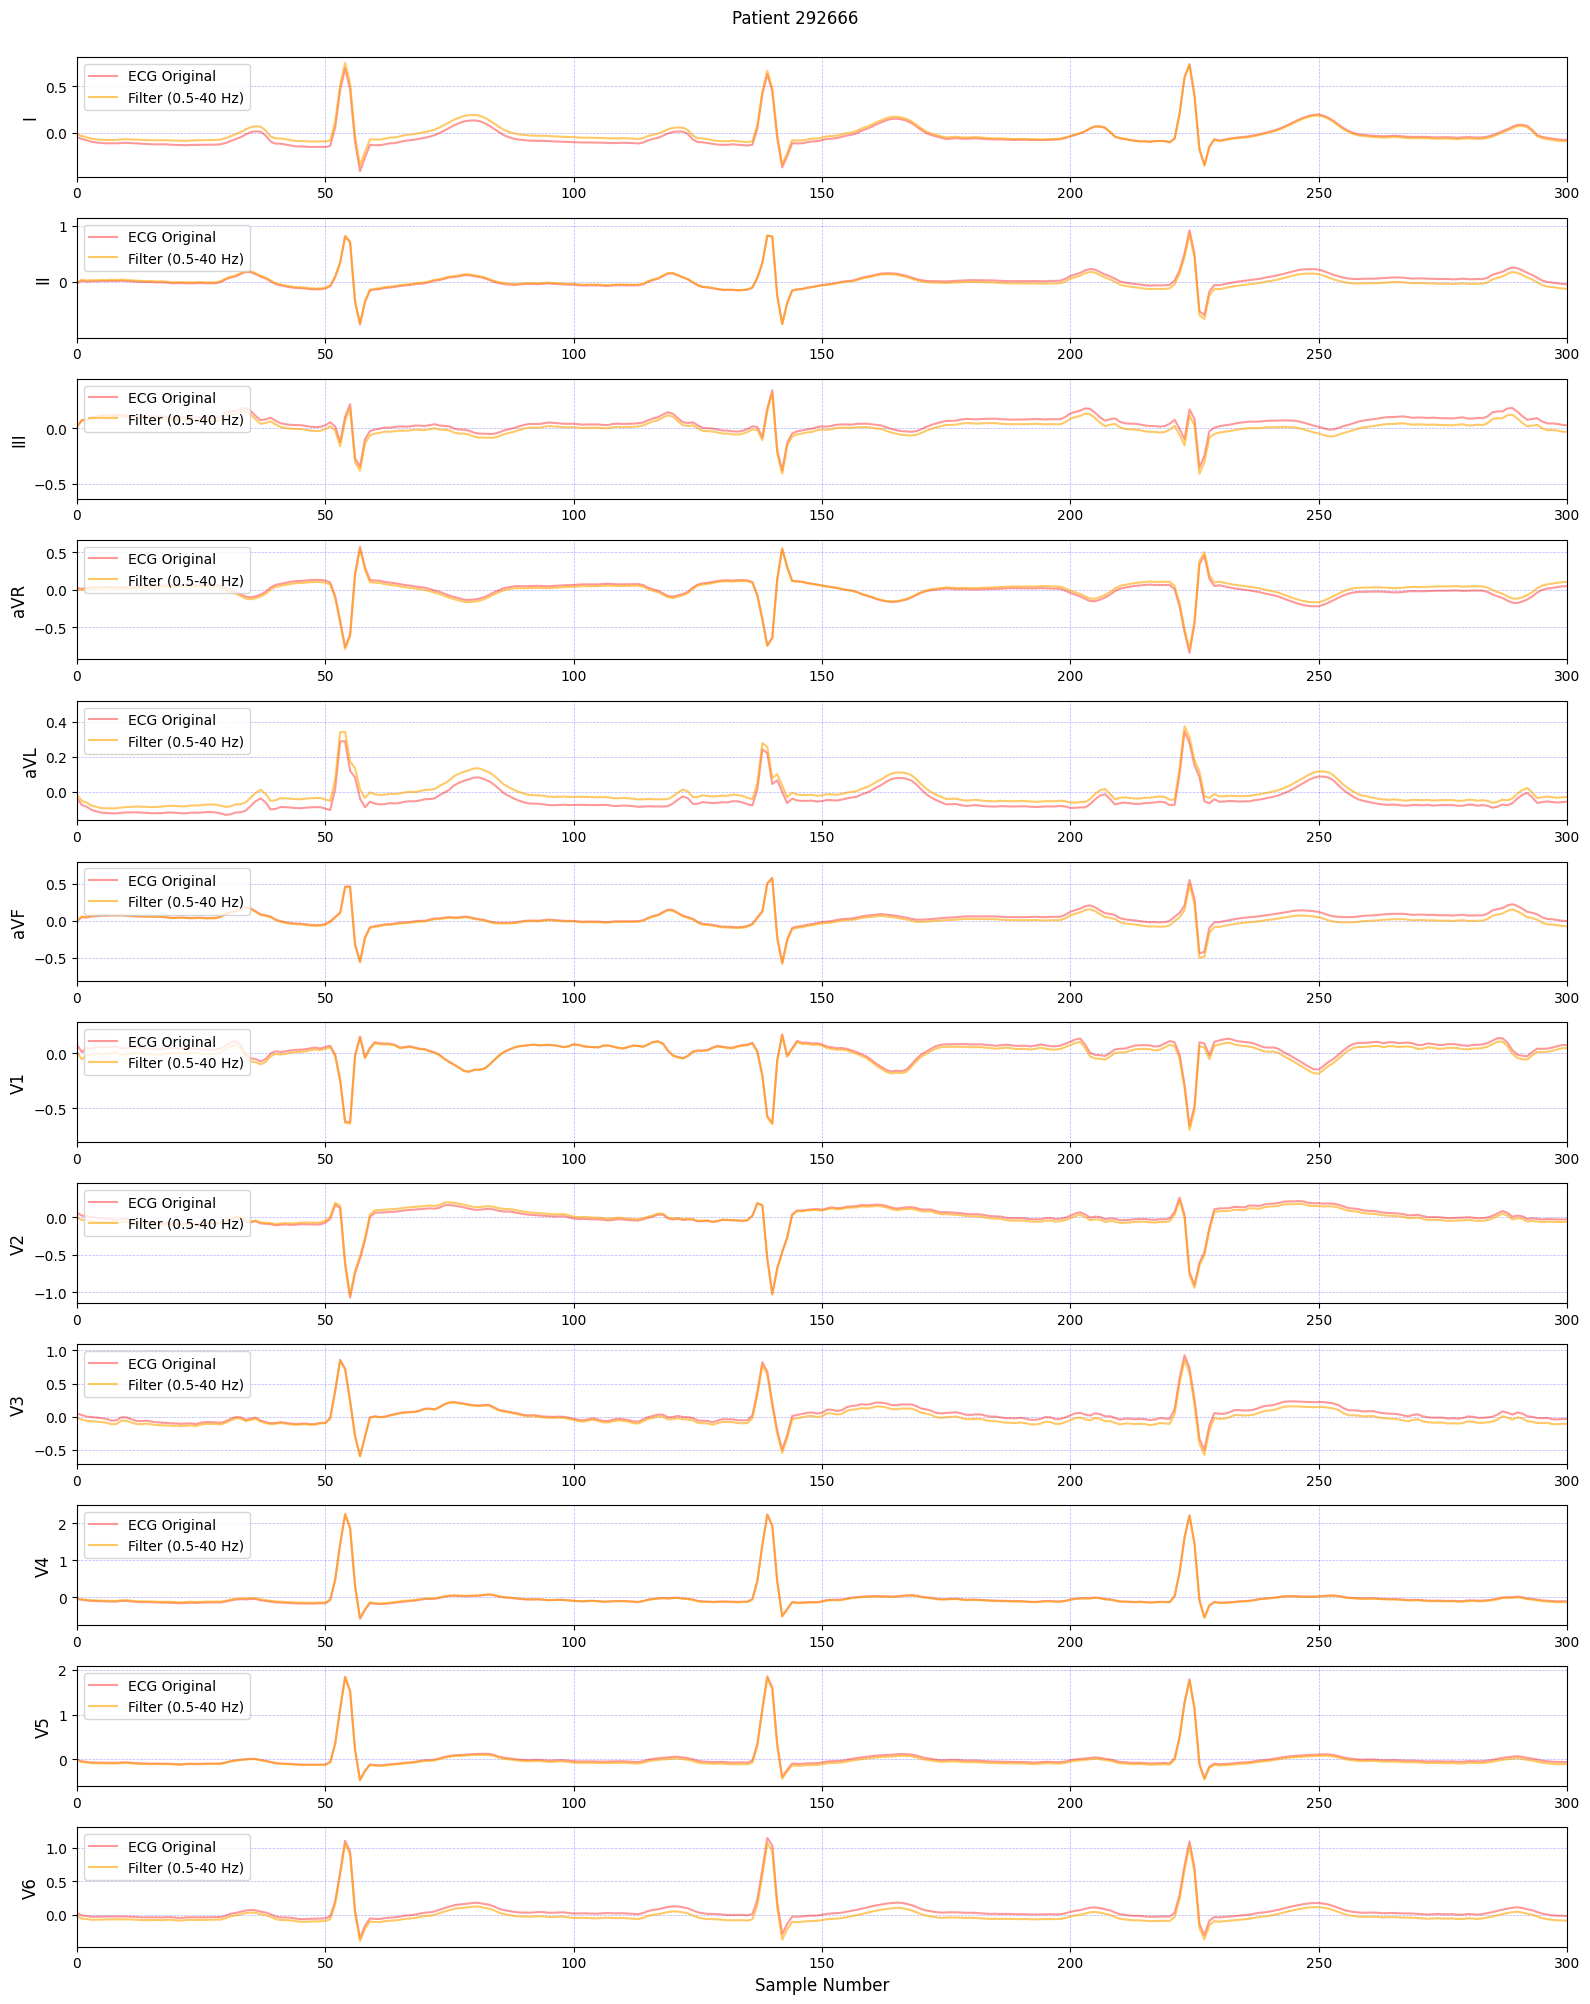

In [146]:
fig, axes = plt.subplots(12, 1, figsize=(16, 20))

for i, lead_name in enumerate(lead_names):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red', alpha=0.4)
  axes[i].plot(clean_baseline_wonder[:, i], linewidth=1.5, color='orange', alpha=0.6)
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].legend(['ECG Original', 'Filter (0.5-40 Hz)'], loc="upper left")
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='blue', alpha=0.3)

  # focusing waveform at specific time (0, duration)
  axes[i].set_xlim(0, 300) 

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()


#### Notch Filter
Notch filter digunakan untuk menghilangkan frekuensi tertentu yang sering kali merupakan sumber noise pada sinyal ECG, seperti frekuensi listrik 50 Hz. Filter ini bekerja dengan cara memblokir frekuensi tertentu tanpa mempengaruhi frekuensi lainnya, sehingga membantu dalam meningkatkan kualitas sinyal ECG untuk analisis lebih lanjut.

In [147]:
def _notch_filter(freq: float, fs: float, quality: float = 30.0):
  b, a = iirnotch(freq, quality, fs)
  return b, a


In [148]:
def notch_filter(signal, freq: float = 50.0, fs: float = 100.0) -> np.ndarray:
  b, a = _notch_filter(freq, fs)
  return filtfilt(b, a, signal)


In [149]:
clean_notch_filter = np.zeros_like(signals)
for lead_index in range(signals.shape[1]):
  lead = signals[:, lead_index]
  lead = remove_baseline_wander(lead, fs=sampling_freq)
  
  clean_notch_filter[:, lead_index] = lead

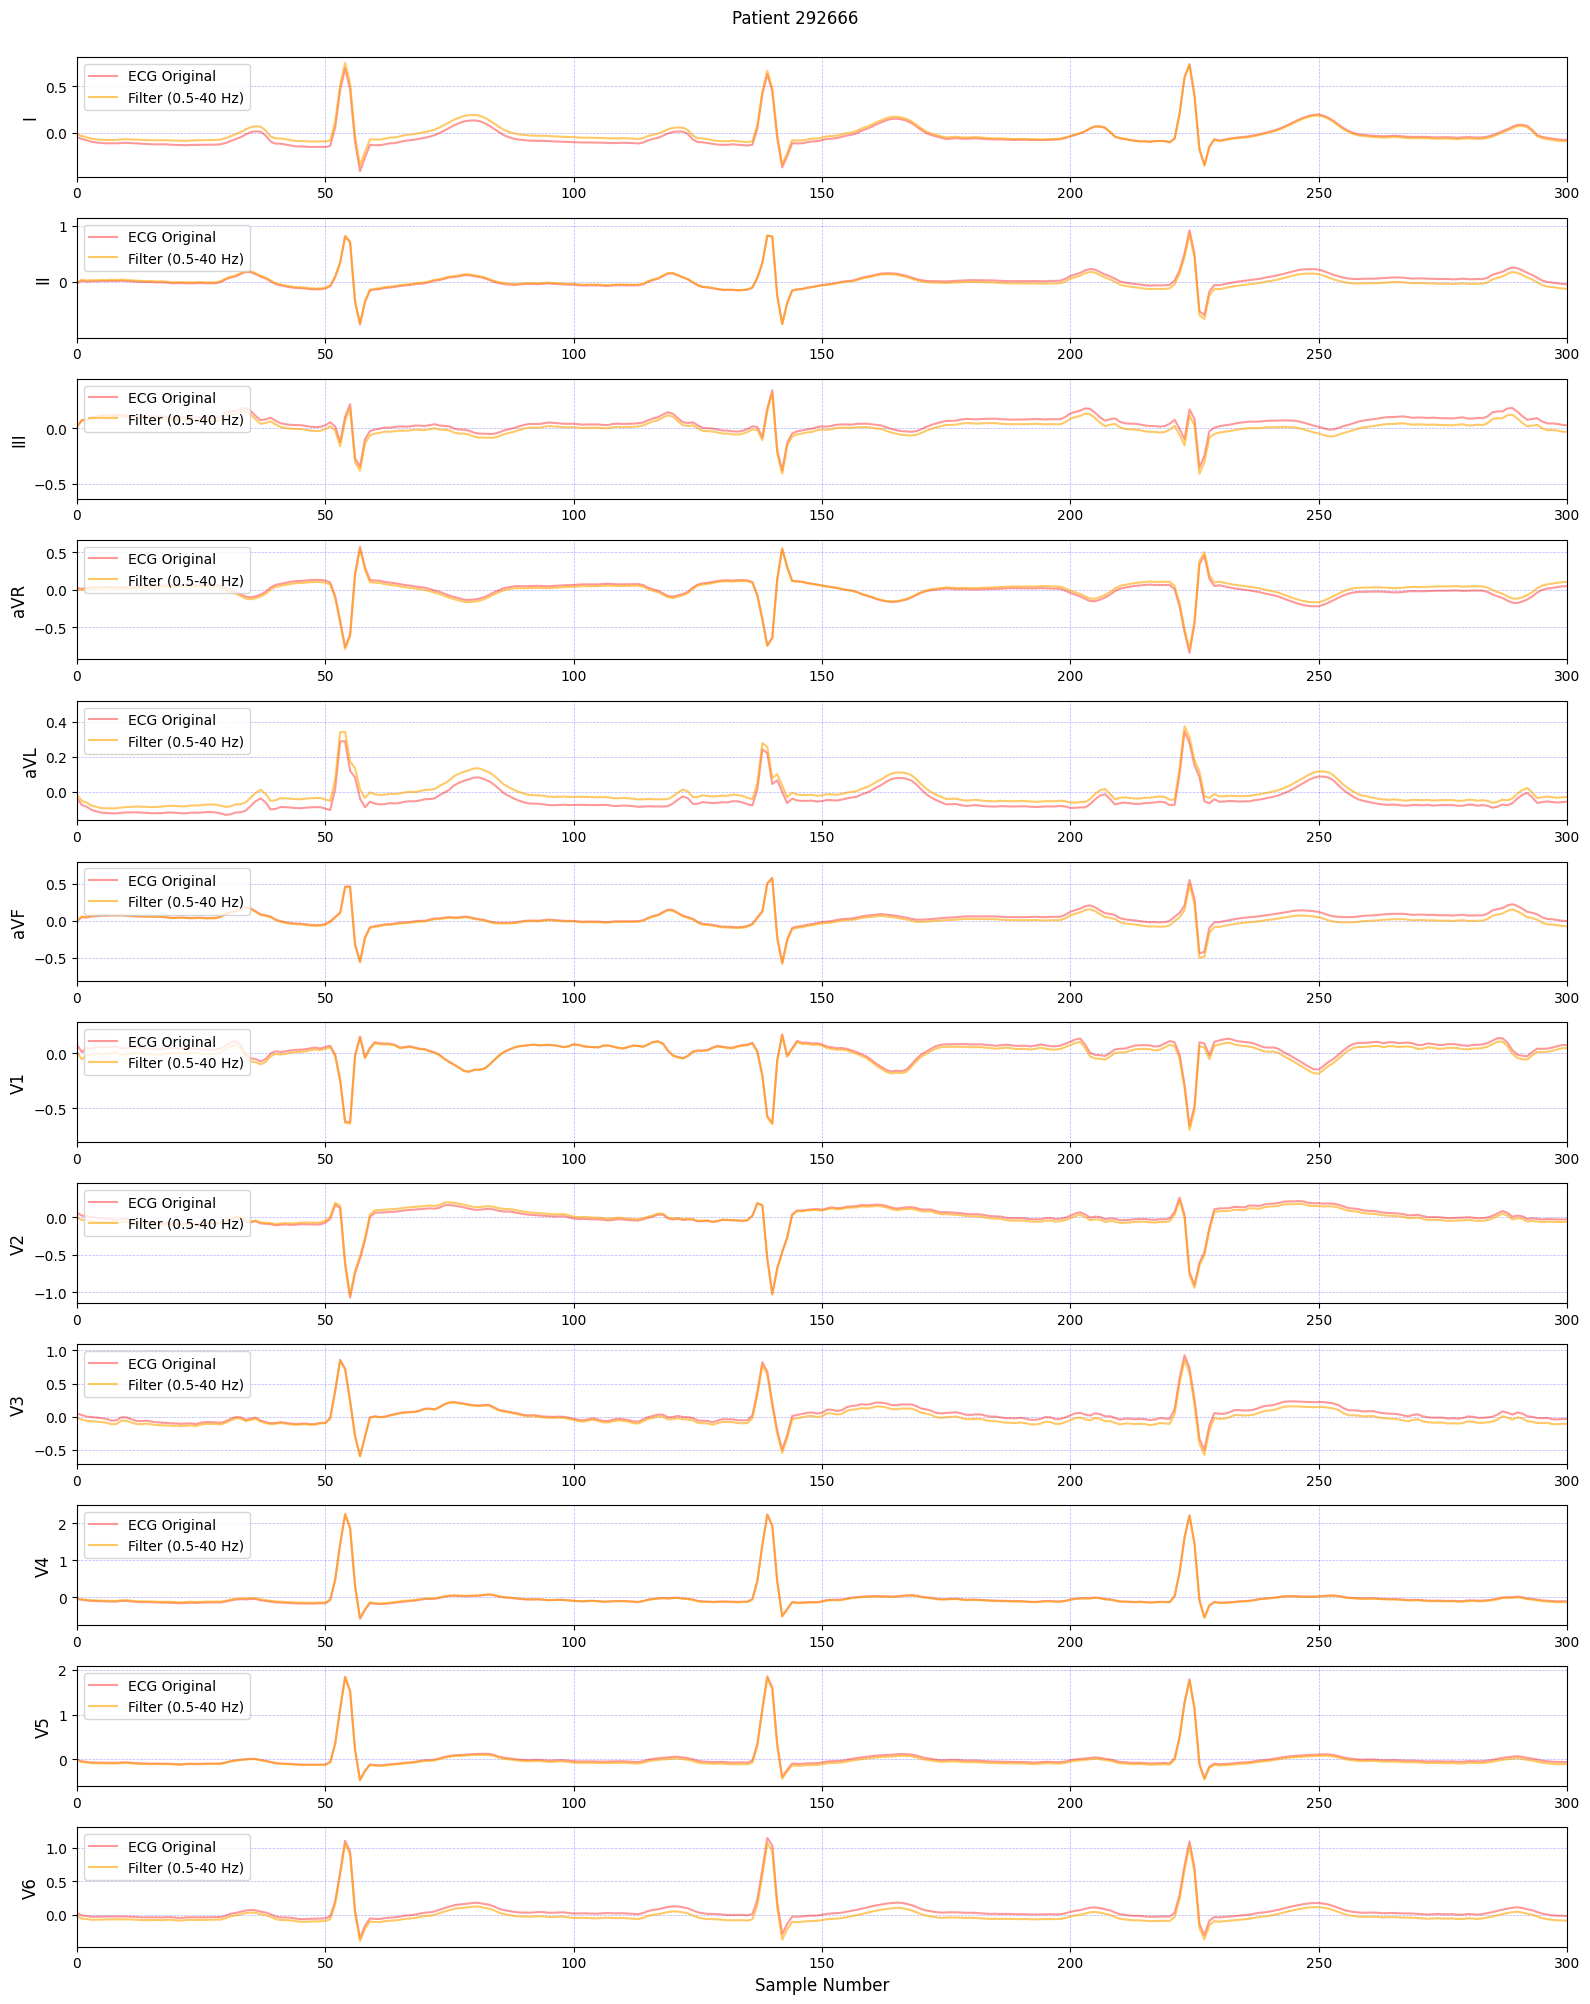

In [150]:
fig, axes = plt.subplots(12, 1, figsize=(16, 20))

for i, lead_name in enumerate(lead_names):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red', alpha=0.4)
  axes[i].plot(clean_notch_filter[:, i], linewidth=1.5, color='orange', alpha=0.6)
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].legend(['ECG Original', 'Filter (0.5-40 Hz)'], loc="upper left")
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='blue', alpha=0.3)

  # focusing waveform at specific time (0, duration)
  axes[i].set_xlim(0, 300) 

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()


#### Wavelet Denoising


In [154]:
def wavelet_denoise(signal, wavelet='db4', level=4, threshold_scale=1.0):
  # Decompose
  coeffs = pywt.wavedec(signal, wavelet, level=level)
  
  # Calculate threshold
  sigma = np.median(np.abs(coeffs[-1])) / 0.6745
  threshold = threshold_scale * sigma * np.sqrt(2 * np.log(len(signal)))
  
  # Threshold (keep approximation, threshold details)
  coeffs_thresh = coeffs.copy()
  for i in range(1, len(coeffs)):
    coeffs_thresh[i] = pywt.threshold(coeffs[i], threshold, mode='soft')
  
  # Reconstruct
  denoised = pywt.waverec(coeffs_thresh, wavelet)
  
  # Adjust length
  if len(denoised) > len(signal):
    denoised = denoised[:len(signal)]
  
  return denoised

#### Z-score Normalization
Z-score normalization digunakan untuk mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1. Hal ini membantu dalam mengurangi efek dari skala yang berbeda pada fitur-fitur yang digunakan dalam model machine learning. Dengan melakukan normalisasi, model dapat lebih mudah belajar dari data dan meningkatkan performa model.

In [151]:
def zscore_normalise(data: pd.DataFrame):
  std_dev = data.std(axis=0)
  z_scores = (data - data.mean(axis=0)) / std_dev
  
  return z_scores

In [155]:
def preprocess_record(signal: np.ndarray, fs: float = 100):
  clean = np.zeros_like(signal)

  for lead_index in range(signal.shape[1]):
    lead = signal[:, lead_index]
    lead = butter_bandpass_filter(lead, lowcut=0.5, highcut=40.0, fs=fs)
    # lead = notch_filter(lead, freq=50.0, fs=fs)
    lead = remove_baseline_wander(lead, fs=fs)
    lead = wavelet_denoise(lead, wavelet='db4', level=4, threshold_scale=1.0)
    lead = zscore_normalise(lead)

    clean[:, lead_index] = lead

  return clean

def preprocess_dataset(data: np.ndarray, fs: float = 100): 
  X_clean = np.zeros_like(data)
  for i in tqdm(range(data.shape[0])):
    X_clean[i] = preprocess_record(data[i], fs)
  return X_clean

In [182]:
X_clean = preprocess_record(signals)

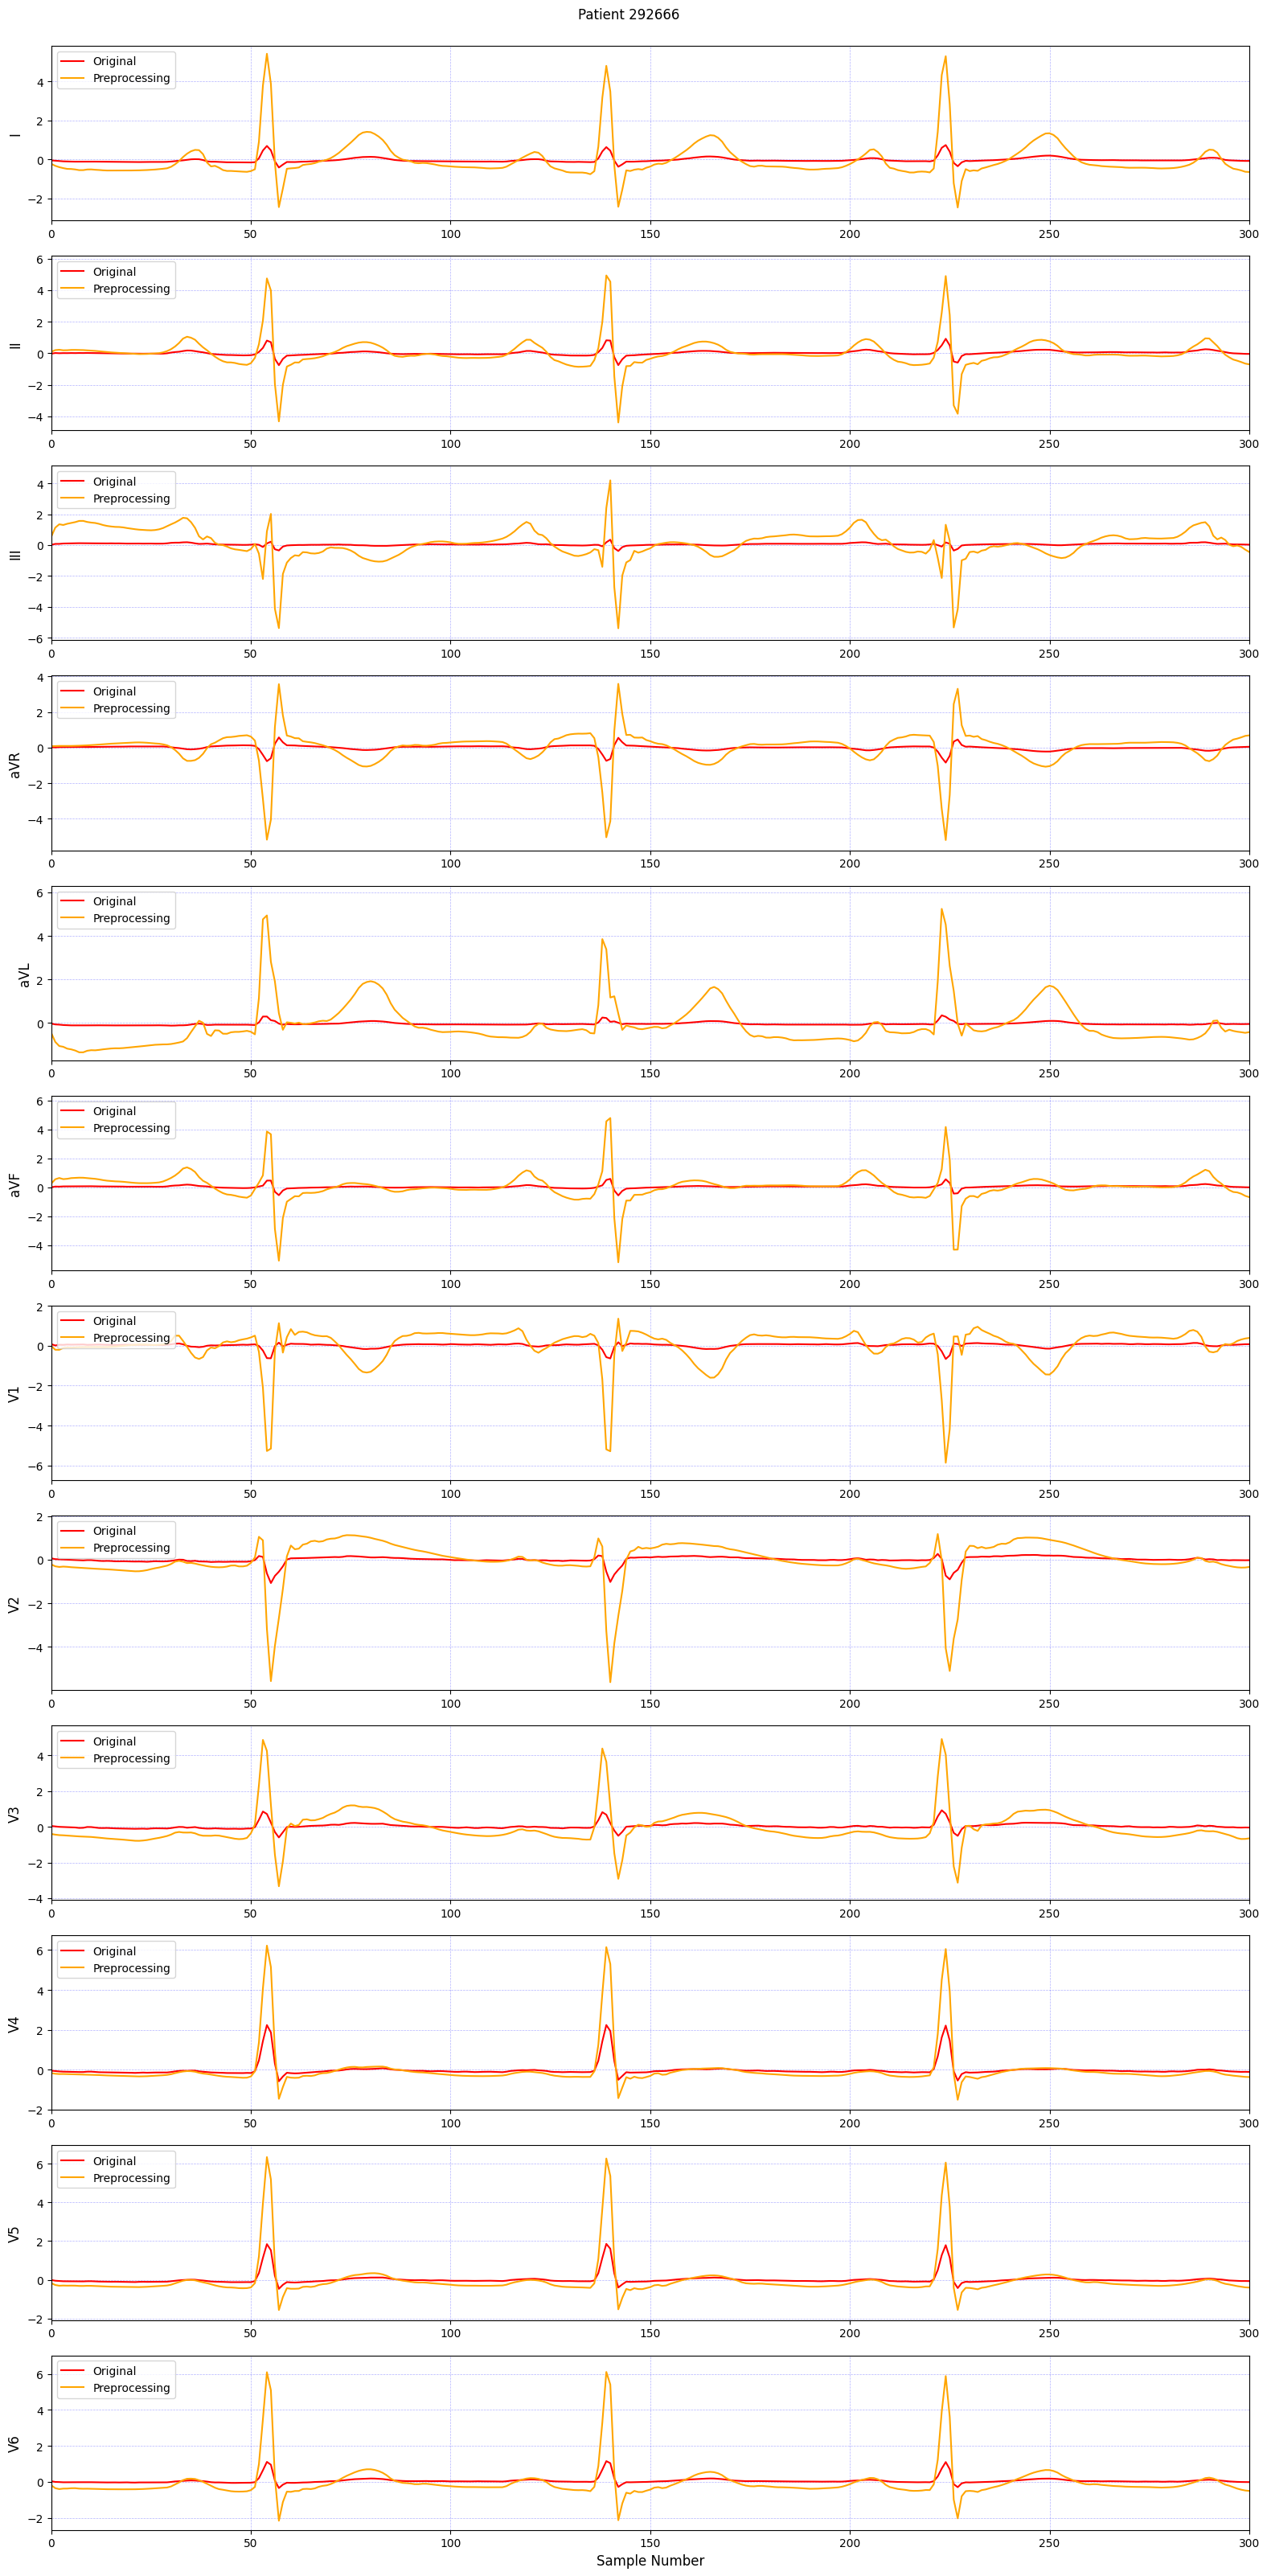

In [158]:
fig, axes = plt.subplots(12, 1, figsize=(16, 32))

for i, lead_name in enumerate(lead_names):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red')
  axes[i].plot(X_clean[:, i], linewidth=1.5, color='orange')
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].legend(['Original', 'Preprocessing'], loc="upper left")
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='blue', alpha=0.3)

  # focusing waveform at specific time (0, duration)
  axes[i].set_xlim(0, 300) 

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()

### Feature Extraction


In [159]:
from scipy.signal import find_peaks

#### Time Domain Features

In [160]:
def time_domain_features(signal: np.ndarray):
  features_list = []

  for i in range(signal.shape[1]):
    lead = signal[:, i]

    features_list.extend([
      lead.mean(),
      lead.std(),
      np.sqrt(np.mean(lead ** 2))
    ])

  return np.array(features_list, dtype=np.float32)

In [161]:
time_domain = time_domain_features(X_clean)
print(f"Min max time_domain features: {time_domain}")
print(f"Min max time_domain features: {len(time_domain)}")

Min max time_domain features: [ 4.4408920e-18  1.0000000e+00  1.0000000e+00  1.4802974e-18
  1.0000000e+00  1.0000000e+00  1.0362082e-17  1.0000000e+00
  1.0000000e+00 -1.9243866e-17  1.0000000e+00  1.0000000e+00
 -2.9605949e-17  1.0000000e+00  1.0000000e+00 -2.2204460e-18
  1.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00
  1.0000000e+00  8.8817840e-18  1.0000000e+00  1.0000000e+00
 -2.9605948e-18  1.0000000e+00  1.0000000e+00 -1.3322676e-17
  1.0000000e+00  1.0000000e+00  1.0362082e-17  1.0000000e+00
  1.0000000e+00 -8.1416352e-18  1.0000000e+00  1.0000000e+00]
Min max time_domain features: 36


#### Detect R-peaks

In [162]:
def detect_r_peaks(lead: np.ndarray, fs: int = 100):
  # gunakan lead II
  ecg = lead.copy()

  # bandpass untuk menonjolkan QRS
  ecg_f = butter_bandpass_filter(ecg, lowcut=0.5, highcut=40.0, fs=fs)

  # square untuk menonjolkan peak
  ecg_sq = ecg_f ** 2

  # adaptive threshold
  thresh = np.mean(ecg_sq) + 0.5 * np.std(ecg_sq)

  min_dist = int(0.4 * fs)

  peaks, _ = find_peaks(
      ecg_sq,
      height=thresh,
      distance=min_dist
  )

  return peaks

In [163]:
lead = X_clean[:, 1]  

r_peaks = detect_r_peaks(lead, fs=sampling_freq)
print(f"Detected {len(r_peaks)} R-peaks")
print(f"Peak indices: {r_peaks}")

Detected 14 R-peaks
Peak indices: [  54  139  224  309  394  479  565  651  736  820  902  982 1061 1141]


#### ST Segment Analysis

In [164]:
def st_segment_features(signal: np.ndarray, fs: float = 100.0):
  """Extract ST segment features from V1, V2, V3"""
  
  leads_of_interest = [6, 7, 8]  # V1, V2, V3
  st_feats = []
  
  # Detect R peaks (dari lead II)
  r_peaks = detect_r_peaks(signal[:, 1], fs)
  
  if len(r_peaks) == 0:
    return np.zeros(6, dtype=np.float32)  # 3 leads × 2 features
  
  for lead_idx in leads_of_interest:
    lead = signal[:, lead_idx]
    st_values = []
    
    for r_peak in r_peaks:
      # Baseline: 300-120ms before R peak
      base_start = max(0, r_peak - int(0.30 * fs))
      base_end = max(0, r_peak - int(0.12 * fs))
      
      if base_start >= base_end:
          continue
      
      baseline = np.mean(lead[base_start:base_end])
      
      # ST segment: 80ms after R peak
      st_idx = r_peak + int(0.08 * fs)
      
      if st_idx >= len(lead):
          continue
      
      st_val = lead[st_idx] - baseline
      st_values.append(st_val)
    
    # Features: mean & std
    if len(st_values) > 0:
      st_feats.append(np.mean(st_values))
      st_feats.append(np.std(st_values))
    else:
      st_feats.append(0.0)
      st_feats.append(0.0)

  return np.array(st_feats, dtype=np.float32)

In [165]:
st = st_segment_features(X_clean, fs=sampling_freq)
print("ST features:", st)

ST features: [0.44601026 0.14977674 0.613965   0.10871422 0.40112138 0.1434695 ]


In [166]:
def st_slope_features(signal: np.ndarray, fs: float = 100.0):
  features = []
  leads_of_interest = [6, 7, 8]  # V1 V2 V3
  
  r_peaks = detect_r_peaks(signal[:, 1], fs)
  
  for lead_idx in leads_of_interest:
    lead = signal[:, lead_idx]
    slopes = []
    
    for r in r_peaks:
      # ST slope: 60-100ms after R peak
      p1 = r + int(0.06 * fs)  # 60ms
      p2 = r + int(0.10 * fs)  # 100ms
      
      if p2 >= len(lead):
          continue
      
      slope = (lead[p2] - lead[p1]) / (0.04)  # 0.04s = 40ms
      slopes.append(slope)
    
    if len(slopes) > 0:
      features.extend([np.mean(slopes), np.std(slopes)])
    else:
      features.extend([0.0, 0.0])
  
  return np.array(features, dtype=np.float32)

In [167]:
slope = st_slope_features(X_clean, fs=sampling_freq)
print("ST slope features:", slope)

ST slope features: [-3.0772667  3.5935206  4.9071293  3.8654995 10.298717   5.110007 ]


#### Min-max amplitude

In [168]:
def min_max_amplitude(signal: np.ndarray, fs: float = 100.0):
  features = []

  for lead_idx in range(signal.shape[1]):
    lead = signal[:, lead_idx]

    min_amp = np.min(lead)
    max_amp = np.max(lead)

    amplitude_range = max_amp - min_amp

    features.extend([
      min_amp, max_amp, amplitude_range
    ])
  
  return np.array(features, dtype=np.float32)

In [169]:
amplitude = min_max_amplitude(X_clean, fs=sampling_freq)
print(f"Min max amplitude features: {amplitude}")

Min max amplitude features: [-2.7187803  5.417084   8.135865  -4.3792596  5.672045  10.051305
 -5.6638923  4.632711  10.296603  -5.3222747  3.5978363  8.920111
 -1.3589499  5.9448166  7.3037663 -5.1875925  5.785022  10.972614
 -6.3416214  1.6151086  7.95673   -5.632676   1.6663005  7.298977
 -3.6593163  5.2352567  8.894573  -1.623639   6.333491   7.95713
 -1.6634517  6.530032   8.193484  -2.2390869  6.5889463  8.828033 ]


#### QRS Features

In [170]:
def qrs_features(signal: np.ndarray, fs: float = 100.0):
  """Extract QRS features from Lead II
  
  Returns:
      - Mean QRS amplitude (peak-to-peak)
      - Std QRS amplitude
      - Mean QRS duration (ms)
      - Number of R peaks detected
  """
  
  lead = signal[:, 1]  # Lead II
  r_peaks = detect_r_peaks(lead, fs)
  
  if len(r_peaks) == 0:
    return np.zeros(4, dtype=np.float32)
  
  amplitudes = []
  durations = []
  
  for r_peak in r_peaks:
    # Window: ±100ms around R peak
    window_size = int(0.10 * fs)
    lo = max(0, r_peak - window_size)
    hi = min(len(lead), r_peak + window_size)
    
    segment = lead[lo:hi]
    
    # Feature 1: Amplitude (peak-to-peak)
    amplitude = np.max(segment) - np.min(segment)
    amplitudes.append(amplitude)
    
    # Feature 2: Duration using derivative
    derivative = np.abs(np.diff(segment))
    threshold = 0.1 * np.max(derivative)
    
    active_indices = np.where(derivative > threshold)[0]
    
    if len(active_indices) >= 2:
      # Duration in milliseconds
      duration_ms = (active_indices[-1] - active_indices[0]) / fs * 1000
      durations.append(duration_ms)
  
  # Calculate statistics
  mean_amplitude = np.mean(amplitudes) if amplitudes else 0.0
  std_amplitude = np.std(amplitudes) if amplitudes else 0.0
  mean_duration = np.mean(durations) if durations else 0.0
  n_beats = len(r_peaks)
  
  return np.array([
    mean_amplitude,
    std_amplitude,
    mean_duration,
    n_beats
  ], dtype=np.float32)

In [171]:
qrs = qrs_features(X_clean, fs=sampling_freq)
print("QRS features:", qrs)

QRS features: [ 9.0583935  0.1964029 66.42857   14.       ]


In [172]:
def rprime_features(signal: np.ndarray, fs: float = 100.0):
  """Extract R' (R prime) features from V1, V2
  
  R' = second peak dalam QRS complex
  Brugada: R' sering prominent di V1-V2
  """
  
  leads_of_interest = [6, 7]  # V1, V2
  feats = []
  
  r_peaks = detect_r_peaks(signal[:, 1], fs)
  
  if len(r_peaks) == 0:
    return np.zeros(4, dtype=np.float32)
  
  for lead_idx in leads_of_interest:
    lead = signal[:, lead_idx]
    rprime_vals = []
    
    for r_peak in r_peaks:
      # Window: 20-120ms after R peak (100ms window)
      start_idx = r_peak + int(0.02 * fs)   # 20ms
      end_idx = r_peak + int(0.12 * fs)     # 120ms
      
      if end_idx >= len(lead) or start_idx < 0:
        continue
      
      segment = lead[start_idx:end_idx]
      
      # Find peaks dengan prominence
      from scipy.signal import find_peaks
      
      if len(segment) < 3:
        continue
      
      peaks, properties = find_peaks(
        segment,
        prominence=0.2 * np.max(np.abs(segment))
      )
      
      if len(peaks) > 0:
        # Get highest peak (R')
        rprime_height = np.max(segment[peaks])
        rprime_vals.append(rprime_height)
    
    # Features: mean & std
    if len(rprime_vals) > 0:
      feats.append(np.mean(rprime_vals))
      feats.append(np.std(rprime_vals))
    else:
      feats.append(0.0)
      feats.append(0.0)
  
  return np.array(feats, dtype=np.float32)

In [173]:
rp = rprime_features(X_clean, fs=sampling_freq)
print("R' features:", rp)

R' features: [0.90223867 0.19037235 0.         0.        ]


In [174]:
def morphological_features(signal: np.ndarray, fs: float = 100.0):
  """Extract all morphological features
  
  Returns concatenated features from:
  - ST segment (6 features: 3 leads × 2 stats)
  - ST slope (6 features: 3 leads × 2 stats)
  - QRS (4 features)
  - R' (4 features)
  
  Total: 20 features
  """
  
  # Extract individual feature groups
  st = st_segment_features(signal, fs)
  slope = st_slope_features(signal, fs)
  qrs = qrs_features(signal, fs)
  rprime = rprime_features(signal, fs)
  
  # Concatenate
  features = np.concatenate([st, slope, qrs, rprime])
  
  return features.astype(np.float32)

In [175]:
def qt_interval_features(signal: np.ndarray, fs: float = 100.0):
  """Extract QT interval features from lead II
  
  QT interval = Q wave start to T wave end
  QTc = QT / sqrt(RR) (heart-rate corrected)
  """
  
  lead = signal[:, 1]  # Lead II
  r_peaks = detect_r_peaks(lead, fs)
  
  if len(r_peaks) < 2:
    return np.zeros(3, dtype=np.float32)
  
  qt_intervals = []
  rr_intervals = []
  
  for i, r_peak in enumerate(r_peaks[:-1]):
    # RR interval in seconds
    rr_ms = (r_peaks[i+1] - r_peak) / fs * 1000
    rr_intervals.append(rr_ms)
    
    # Estimate T-wave end (~400ms after R-peak for normal ECG)
    t_end_idx = min(r_peak + int(0.400 * fs), len(lead) - 1)
    
    # QT duration (simplified: from R peak to estimated T-end)
    qt_ms = (t_end_idx - r_peak) / fs * 1000
    qt_intervals.append(qt_ms)
  
  if len(qt_intervals) == 0:
    return np.zeros(3, dtype=np.float32)
  
  qt_mean = np.mean(qt_intervals)
  rr_mean = np.mean(rr_intervals)
  qtc = qt_mean / np.sqrt(rr_mean / 1000) if rr_mean > 0 else 0.0
  
  return np.array([qt_mean, np.std(qt_intervals), qtc], dtype=np.float32)


def pr_segment_features(signal: np.ndarray, fs: float = 100.0):
  """Extract PR segment features
  
  PR segment = baseline electrical activity before QRS
  """
  
  leads_of_interest = [1, 2]  # II, III
  pr_feats = []
  
  r_peaks = detect_r_peaks(signal[:, 1], fs)
  
  if len(r_peaks) == 0:
    return np.zeros(4, dtype=np.float32)
  
  for lead_idx in leads_of_interest:
    lead = signal[:, lead_idx]
    pr_values = []
    
    for r_peak in r_peaks:
      # PR segment: 200ms before R peak
      pr_start = max(0, r_peak - int(0.20 * fs))
      pr_end = r_peak
      
      if pr_start >= pr_end:
        continue
      
      pr_segment = lead[pr_start:pr_end]
      pr_std = np.std(pr_segment)
      pr_values.append(pr_std)
    
    if len(pr_values) > 0:
      pr_feats.append(np.mean(pr_values))
      pr_feats.append(np.std(pr_values))
    else:
      pr_feats.extend([0.0, 0.0])
  
  return np.array(pr_feats, dtype=np.float32)


def twave_morphology_features(signal: np.ndarray, fs: float = 100.0):
  """Extract T-wave morphology from V1, V2, V3
  
  Features:
  - T-wave amplitude in V1-V3
  - T-wave asymmetry (rise time vs fall time)
  - Negative T-wave prevalence (Brugada marker)
  """
  
  leads_of_interest = [6, 7, 8]  # V1, V2, V3
  twave_feats = []
  
  r_peaks = detect_r_peaks(signal[:, 1], fs)
  
  if len(r_peaks) == 0:
    return np.zeros(9, dtype=np.float32)
  
  for lead_idx in leads_of_interest:
    lead = signal[:, lead_idx]
    t_amplitudes = []
    negative_count = 0
    asymmetries = []
    
    for r_peak in r_peaks:
      # T-wave window: 250-500ms after R peak
      t_start = r_peak + int(0.25 * fs)
      t_end = r_peak + int(0.50 * fs)
      
      if t_end >= len(lead):
        continue
      
      t_segment = lead[t_start:t_end]
      
      # Find T-wave peak
      t_peak_idx = np.argmax(np.abs(t_segment))
      t_amplitude = t_segment[t_peak_idx]
      t_amplitudes.append(abs(t_amplitude))
      
      # Negative T-wave indicator
      if t_amplitude < -0.1:
        negative_count += 1
      
      # Asymmetry: ratio of rise time to fall time
      if t_peak_idx > 0:
        rise_time = t_peak_idx
        fall_time = len(t_segment) - t_peak_idx
        if fall_time > 0:
          asymmetries.append(rise_time / fall_time)
    
    # Features: amplitude, negative_ratio, asymmetry_mean
    if len(t_amplitudes) > 0:
      twave_feats.append(np.mean(t_amplitudes))
      twave_feats.append(negative_count / len(t_amplitudes))
      twave_feats.append(np.mean(asymmetries) if asymmetries else 0.0)
    else:
      twave_feats.extend([0.0, 0.0, 0.0])
  
  return np.array(twave_feats, dtype=np.float32)


def spectral_features(signal: np.ndarray, fs: float = 100.0):
  """Extract power spectral density features from multiple leads
  
  Features:
  - Power in different frequency bands (0-5Hz, 5-10Hz, 10-20Hz)
  - Spectral entropy
  """
  from scipy.signal import welch
  
  # Use leads: II (rhythm), V1 (morphology)
  leads_of_interest = [1, 6]
  spectral_feats = []
  
  for lead_idx in leads_of_interest:
    lead = signal[:, lead_idx]
    
    # Compute power spectral density
    freqs, pxx = welch(lead, fs, nperseg=256)
    
    # Power bands
    low_power = np.sum(pxx[(freqs >= 0) & (freqs < 5)])
    mid_power = np.sum(pxx[(freqs >= 5) & (freqs < 10)])
    high_power = np.sum(pxx[(freqs >= 10) & (freqs < 20)])
    
    # Spectral entropy (normalized)
    pxx_norm = pxx / np.sum(pxx) if np.sum(pxx) > 0 else pxx
    spectral_entropy = -np.sum(pxx_norm * np.log(pxx_norm + 1e-10))
    
    spectral_feats.extend([
      low_power,
      mid_power,
      high_power,
      spectral_entropy
    ])
  
  return np.array(spectral_feats, dtype=np.float32)


def wavelet_energy_features(signal: np.ndarray, fs: float = 100.0):
  """Extract wavelet energy features from preprocessed signal
  
  Features:
  - Energy in different wavelet decomposition levels
  - Contribution of each level to total energy
  """
  
  lead = signal[:, 6]  # V1 (important for Brugada)
  
  # Wavelet decomposition
  coeffs = pywt.wavedec(lead, 'db4', level=4)
  
  # Calculate energy for each level
  energies = []
  for coeff in coeffs:
    energy = np.sum(coeff ** 2)
    energies.append(energy)
  
  total_energy = np.sum(energies)
  
  if total_energy > 0:
    energy_ratios = [e / total_energy for e in energies]
  else:
    energy_ratios = [0.0] * len(energies)
  
  return np.array(energy_ratios, dtype=np.float32)

#### Extract features

In [176]:
def extract_features(signal: np.ndarray, fs: float = 100.0) -> np.ndarray:
  time_domain = time_domain_features(signal)
  min_max_amp = min_max_amplitude(signal, fs)
  # morph   = morphological_features(signal, fs)
  # qt      = qt_interval_features(signal, fs)
  # pr      = pr_segment_features(signal, fs)
  # twave   = twave_morphology_features(signal, fs)
  # spectral = spectral_features(signal, fs)
  # wavelet_energy = wavelet_energy_features(signal, fs)

  return np.concatenate([time_domain, min_max_amp], axis=0)

In [177]:
features = extract_features(X_clean, fs=sampling_freq)
print("feature length:", len(features))
print(features)

feature length: 72
[ 4.4408920e-18  1.0000000e+00  1.0000000e+00  1.4802974e-18
  1.0000000e+00  1.0000000e+00  1.0362082e-17  1.0000000e+00
  1.0000000e+00 -1.9243866e-17  1.0000000e+00  1.0000000e+00
 -2.9605949e-17  1.0000000e+00  1.0000000e+00 -2.2204460e-18
  1.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00
  1.0000000e+00  8.8817840e-18  1.0000000e+00  1.0000000e+00
 -2.9605948e-18  1.0000000e+00  1.0000000e+00 -1.3322676e-17
  1.0000000e+00  1.0000000e+00  1.0362082e-17  1.0000000e+00
  1.0000000e+00 -8.1416352e-18  1.0000000e+00  1.0000000e+00
 -2.7187803e+00  5.4170842e+00  8.1358652e+00 -4.3792596e+00
  5.6720452e+00  1.0051305e+01 -5.6638923e+00  4.6327109e+00
  1.0296603e+01 -5.3222747e+00  3.5978363e+00  8.9201107e+00
 -1.3589499e+00  5.9448166e+00  7.3037663e+00 -5.1875925e+00
  5.7850218e+00  1.0972614e+01 -6.3416214e+00  1.6151086e+00
  7.9567299e+00 -5.6326761e+00  1.6663005e+00  7.2989769e+00
 -3.6593163e+00  5.2352567e+00  8.8945732e+00 -1.6236390e+00
  6.3

In [178]:
def build_feature_matrix(X: np.ndarray, fs: float = 100) -> np.ndarray:
    """
    Extract features for every recording in the dataset.

    Parameters
    ----------
    X : np.ndarray, shape (N, N_SAMPLES, 12)

    Returns
    -------
    F : np.ndarray, shape (N, 123)
    """
    features = []
    for i in tqdm(range(X.shape[0]), desc="Extracting features"):
        features.append(extract_features(X[i], fs))
    return np.stack(features, axis=0)

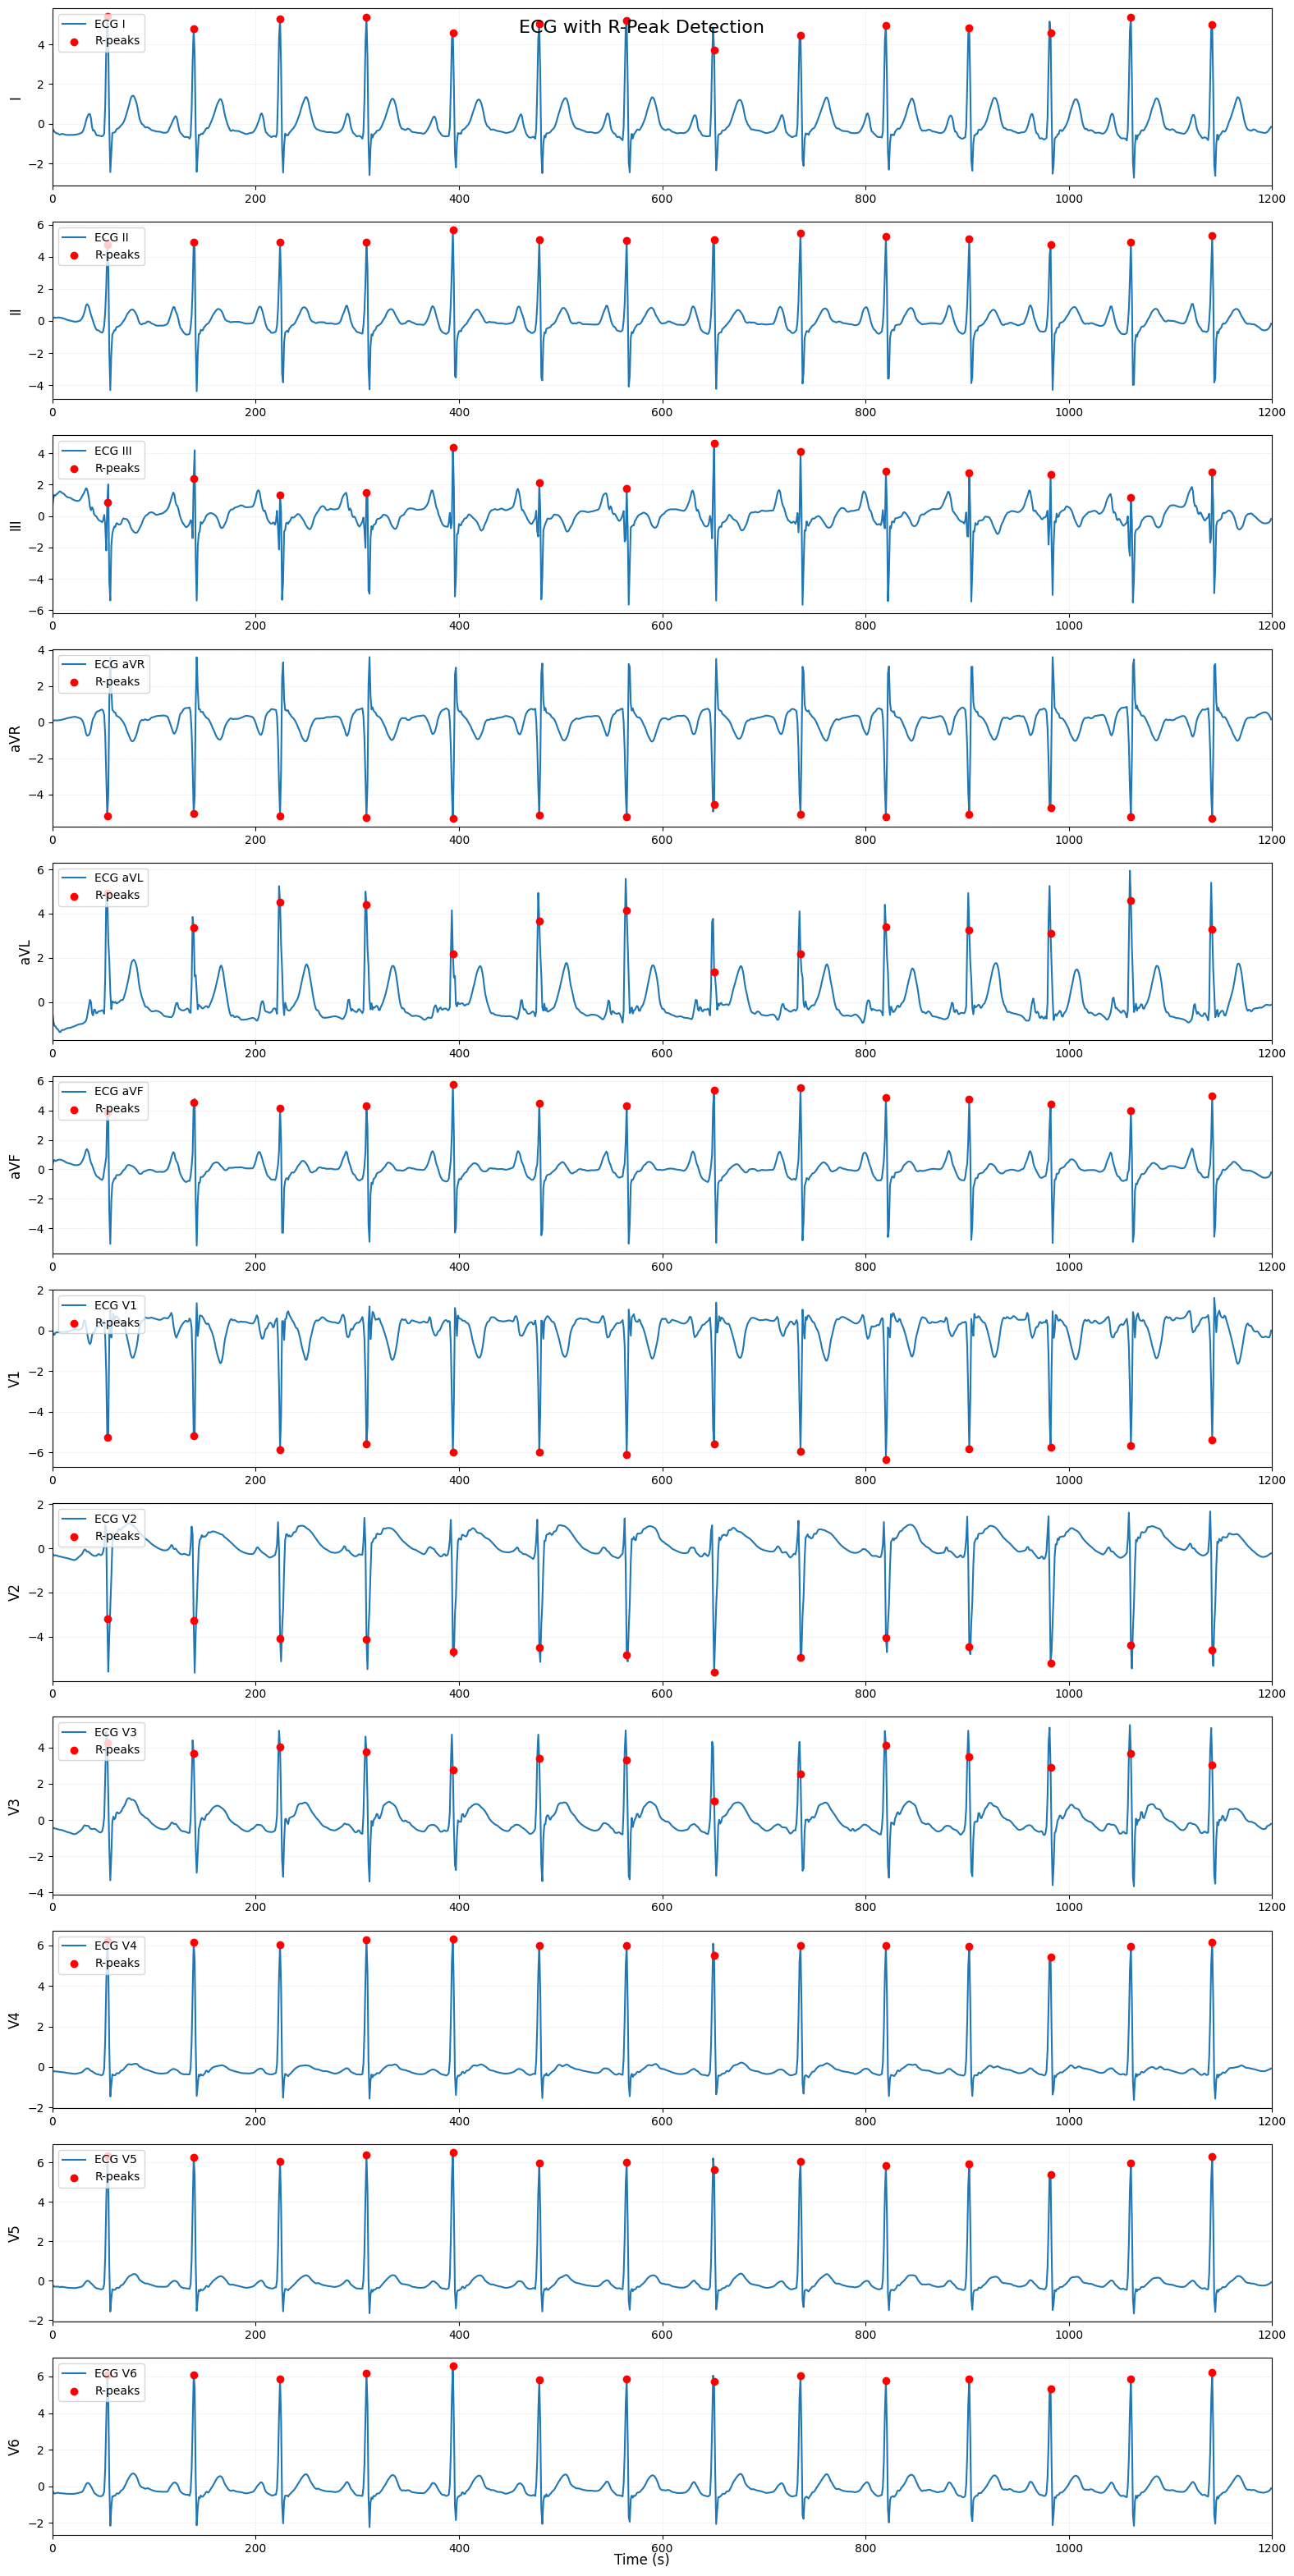

In [179]:
fig, axes = plt.subplots(12, 1, figsize=(16, 32))

for i, lead_name in enumerate(lead_names):
    axes[i].plot(np.arange(duration), X_clean[:, i], label=f"ECG {lead_name}")
    axes[i].scatter(np.arange(duration)[r_peaks], X_clean[r_peaks, i], color="red", label="R-peaks", zorder=5)
    axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
    axes[i].legend(loc="upper left")
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.3)

    axes[i].set_xlim(0, 1200)


fig.supxlabel("Time (s)")
fig.suptitle("ECG with R-Peak Detection", fontsize=16)

plt.tight_layout()

plt.show()

### Load All Dataset

In [180]:
from tqdm import tqdm
import os

DATA_PATH = "./files"

def get_patient_dirs(data_path):
  """Get sorted list of patient directories"""
  dirs = []
  for dir in os.listdir(data_path):
    if os.path.isdir(os.path.join(data_path, dir)):
      dirs.append(dir)

  return sorted(dirs)

def get_hea_file(patient_path):
  """Find .hea file in patient directory"""
  for hea_file in os.listdir(patient_path):
    if hea_file.endswith('.hea'):
      return hea_file
  return None

def load_record(file_path):
  """Load single ECG record"""
  return wfdb.rdrecord(file_path)


def load_ecg_dataset(data_path):
  patient_dirs = get_patient_dirs(data_path)

  signals = []
  patient_ids = []
  labels = []
  lead_names = None
  sampling_freq = None

  meta_dict = dict(zip(metadata['patient_id'].astype(str), metadata['brugada']))

  for patient_id in tqdm(patient_dirs):

    if patient_id not in meta_dict:
      continue

    patient_path = os.path.join(data_path, patient_id)
    hea_file = get_hea_file(patient_path)
    
    if not hea_file:
      continue

    try:
      file_path = os.path.join(patient_path, hea_file[:-4])
      record = load_record(file_path)

      signals.append(record.p_signal)
      patient_ids.append(patient_id)
      labels.append(meta_dict[patient_id])

      if lead_names is None:
        lead_names = list(record.sig_name)
        sampling_freq = record.fs

    except Exception as e:
      print(f"Error {patient_id}: {e}")
    
  X = np.array(signals)
  y = np.array(labels)
  
  return X, y, np.array(patient_ids), lead_names, sampling_freq

In [181]:
X_raw, y, patient_ids, lead_names, fs = load_ecg_dataset(DATA_PATH)
print(f"X shape: {X_raw.shape}")
print(f"y shape: {y.shape}")

NameError: name 'metadata' is not defined

#### Check number of samples in each class

In [ ]:
n_negative = int((y == 0).sum())
n_positive = int((y > 0).sum())

In [ ]:
# Convert target to binary (0 or 1)
y = (y > 0).astype(int)

In [ ]:
print(f"Negative {n_negative}, Positive {n_positive}")

Negative 287, Positive 76


In [ ]:
X_clean = preprocess_dataset(X_raw)

100%|██████████| 363/363 [00:06<00:00, 57.71it/s]


In [ ]:
X_features = build_feature_matrix(X_clean)
print(f'Feature matrix shape: {X_features.shape}')

Extracting features: 100%|██████████| 363/363 [00:00<00:00, 1941.31it/s]

Feature matrix shape: (363, 72)


In [ ]:
print(np.std(X_features, axis=0))

[1.15293923e-17 0.00000000e+00 0.00000000e+00 1.04954413e-17
 0.00000000e+00 0.00000000e+00 1.01059336e-17 0.00000000e+00
 0.00000000e+00 1.09451968e-17 0.00000000e+00 0.00000000e+00
 1.09057113e-17 0.00000000e+00 0.00000000e+00 1.06564586e-17
 0.00000000e+00 0.00000000e+00 9.44015738e-18 0.00000000e+00
 0.00000000e+00 1.15975056e-17 0.00000000e+00 0.00000000e+00
 1.12696667e-17 0.00000000e+00 0.00000000e+00 1.03426710e-17
 0.00000000e+00 0.00000000e+00 1.00178926e-17 0.00000000e+00
 0.00000000e+00 1.05879094e-17 0.00000000e+00 0.00000000e+00
 1.32384872e+00 1.20423222e+00 1.35273457e+00 1.31134605e+00
 1.48897743e+00 1.60287893e+00 1.91221952e+00 2.16570330e+00
 2.25687146e+00 1.14899921e+00 1.23107469e+00 1.30346215e+00
 2.39421797e+00 2.03403711e+00 2.01207304e+00 1.55076599e+00
 1.84070921e+00 1.90782833e+00 1.32495701e+00 1.12765980e+00
 1.46668947e+00 1.35352218e+00 1.17324698e+00 1.53485966e+00
 1.29984367e+00 1.40487492e+00 1.35244787e+00 1.29905689e+00
 1.24185336e+00 1.273812

In [ ]:
def make_feature_names(lead_names):
  """Create feature names for all extracted features"""
  
  # time-domain: 2 per lead (std, rms)
  time_domain_features = []
  for lead_name in lead_names:
    time_domain_features += [f"{lead_name}_mean", f"{lead_name}_std", f"{lead_name}_rms"]
  
  min_max_amp_features = []
  for lead_name in lead_names:
    min_max_amp_features += [f"{lead_name}_min_amp", f"{lead_name}_max_amp", f"{lead_name}_min_max_range"]
  
  # ST elevation
  # st = []
  # for idx in [6, 7, 8]:
  #   ln = lead_names[idx]
  #   st += [f"{ln}_st_mean", f"{ln}_st_std"]
  
  # ST slope
  # st_slope = []
  # for idx in [6, 7, 8]:
  #   ln = lead_names[idx]
  #   st_slope += [f"{ln}_st_slope_mean", f"{ln}_st_slope_std"]
  
  # ST difference
  # st_diff = ["V1_V2_st_diff", "V2_V3_st_diff"]
  
  # QRS
  # qrs = ["qrs_amp_mean", "qrs_amp_std", "qrs_dur_mean_ms", "qrs_count"]
  
  # R'
  # rprime = ["V1_rprime_mean", "V1_rprime_std", "V2_rprime_mean", "V2_rprime_std"]
  
  # QT interval features
  # qt = ["qt_mean_ms", "qt_std_ms", "qtc"]
  
  # PR segment features
  # pr = ["lead_II_pr_mean", "lead_II_pr_std", "lead_III_pr_mean", "lead_III_pr_std"]
  
  # T-wave morphology features
  # twave = []
  # for idx, lead_name in enumerate(["V1", "V2", "V3"]):
  #   twave += [f"{lead_name}_twave_amp", f"{lead_name}_twave_neg_ratio", f"{lead_name}_twave_asymmetry"]
  
  # Spectral features (from Lead II and V1)
  # spectral = [
  #   "lead_II_power_0_5Hz", "lead_II_power_5_10Hz", "lead_II_power_10_20Hz", "lead_II_spectral_entropy",
  #   "V1_power_0_5Hz", "V1_power_5_10Hz", "V1_power_10_20Hz", "V1_spectral_entropy"
  # ]
  
  # Wavelet energy features (5 levels)
  # wavelet = [f"wavelet_level_{i}_energy_ratio" for i in range(5)]
  
  feature_names = time_domain_features +  min_max_amp_features
  
  print(f"Total features: {len(feature_names)}")
  return feature_names

# Test
fnames = make_feature_names(lead_names)
print(fnames)

Total features: 72
['I_mean', 'I_std', 'I_rms', 'II_mean', 'II_std', 'II_rms', 'III_mean', 'III_std', 'III_rms', 'aVR_mean', 'aVR_std', 'aVR_rms', 'aVL_mean', 'aVL_std', 'aVL_rms', 'aVF_mean', 'aVF_std', 'aVF_rms', 'V1_mean', 'V1_std', 'V1_rms', 'V2_mean', 'V2_std', 'V2_rms', 'V3_mean', 'V3_std', 'V3_rms', 'V4_mean', 'V4_std', 'V4_rms', 'V5_mean', 'V5_std', 'V5_rms', 'V6_mean', 'V6_std', 'V6_rms', 'I_min_amp', 'I_max_amp', 'I_min_max_range', 'II_min_amp', 'II_max_amp', 'II_min_max_range', 'III_min_amp', 'III_max_amp', 'III_min_max_range', 'aVR_min_amp', 'aVR_max_amp', 'aVR_min_max_range', 'aVL_min_amp', 'aVL_max_amp', 'aVL_min_max_range', 'aVF_min_amp', 'aVF_max_amp', 'aVF_min_max_range', 'V1_min_amp', 'V1_max_amp', 'V1_min_max_range', 'V2_min_amp', 'V2_max_amp', 'V2_min_max_range', 'V3_min_amp', 'V3_max_amp', 'V3_min_max_range', 'V4_min_amp', 'V4_max_amp', 'V4_min_max_range', 'V5_min_amp', 'V5_max_amp', 'V5_min_max_range', 'V6_min_amp', 'V6_max_amp', 'V6_min_max_range']


In [ ]:
feature_names = make_feature_names(lead_names)
print(len(feature_names))

Total features: 72
72


In [ ]:
features_df = pd.DataFrame(X_features, columns=feature_names)
features_df['label'] = y 

In [ ]:
positive_samples = features_df.query("label > 0")
positive_samples

,I_mean,I_std,I_rms,II_mean,II_std,II_rms,III_mean,III_std,III_rms,aVR_mean,...,V4_min_amp,V4_max_amp,V4_min_max_range,V5_min_amp,V5_max_amp,V5_min_max_range,V6_min_amp,V6_max_amp,V6_min_max_range,label
16,-3.404684e-17,1.0,1.0,-2.960595e-18,1.0,1.0,1.036208e-17,1.0,1.0,5.921190e-18,...,-1.708722,6.017839,7.726561,-1.706184,6.152405,7.858589,-1.294406,6.102635,7.397041,1
22,1.184238e-17,1.0,1.0,-1.184238e-17,1.0,1.0,-2.960595e-18,1.0,1.0,-5.921190e-18,...,-4.959824,2.798484,7.758308,-4.647189,3.130656,7.777844,-4.113743,3.830479,7.944222,1
26,1.332268e-17,1.0,1.0,5.921190e-18,1.0,1.0,7.401487e-18,1.0,1.0,-6.291264e-18,...,-3.938381,4.831013,8.769394,-3.973910,5.737829,9.711739,-7.313781,5.526277,12.840057,1
35,7.401487e-18,1.0,1.0,-6.661338e-18,1.0,1.0,2.960595e-18,1.0,1.0,-1.480297e-17,...,-3.162614,5.696150,8.858765,-2.073171,6.465010,8.538181,-2.706550,6.273781,8.980331,1
38,1.480297e-18,1.0,1.0,-2.960595e-18,1.0,1.0,2.220446e-18,1.0,1.0,1.480297e-17,...,-1.977079,5.100556,7.077635,-1.138630,5.672016,6.810647,-1.273158,5.753192,7.026351,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,2.960595e-18,1.0,1.0,4.440892e-18,1.0,1.0,2.960595e-18,1.0,1.0,1.258253e-17,...,-5.463984,2.341327,7.805312,-5.443429,3.574650,9.018079,-5.410427,3.311319,8.721745,1
351,2.960595e-18,1.0,1.0,-1.184238e-17,1.0,1.0,-7.401487e-18,1.0,1.0,-1.480297e-18,...,-3.372753,5.625583,8.998336,-2.422359,6.043889,8.466248,-2.086076,5.863964,7.950040,1
352,-1.924387e-17,1.0,1.0,-5.921190e-18,1.0,1.0,2.960595e-18,1.0,1.0,7.401487e-18,...,-0.709970,6.425541,7.135511,-0.631773,6.464356,7.096129,-0.775642,6.167278,6.942920,1
354,1.480297e-17,1.0,1.0,1.295260e-17,1.0,1.0,-1.184238e-17,1.0,1.0,9.621933e-18,...,-5.195988,2.332240,7.528228,-4.751785,3.875947,8.627732,-4.076970,4.539019,8.615988,1


In [ ]:
features_df.to_csv('features_file.csv')